In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
import ipywidgets as w

from scipy.optimize import fsolve
from scipy.optimize import root_scalar
from scipy.interpolate import CubicSpline

# Import from other file in repository
from FriedmannEquationCPL import FriedmannEquationCPL

%matplotlib widget

# Dynamics of a Model Universe with CPL-parameterized Dark Energy
### Interactive Visualizer of Friedmann Equation

The cells below are set up to plot
 - the scale factor $a(t)$, the 'size' of the universe relative to today. 
 - the rate of change of the scale factor $\dot{a}(t)$
 - the Hubble parameter $H(t)=\frac{\dot{a}(t)}{a(t)}$, the expansion rate of the universe (Today it equals the Hubble constant $H_0=67.4$ km/s/Mpc).
 - the time-evolving energy densities of the three components (matter, radiation, dark energy) quantified as the dimensionless density parameters $\Omega_{i}(t)$ 
 
as obtained from numerically solving the Friedmann equation for a specified model universe.

The model universe is fixed with $\Lambda$CDM density parameters, however, the CPL parameters $w_0$ and $w_a$ characterizing the nature of the variable dark energy can be set by you using the provided sliders.

You may also choose whether the explicit Runge-Kutta 4(5) solver or the implicit Radau solver is used by the numerical integrator. For the Friedmann equation, it does not tend to make too much of a difference. 

In [43]:
# Global model and parameters
current_model = None
current_w0 = None
current_wa = None
current_method = "RK45"      # Default solver

In [ ]:
def plot_friedmann():
  """
  This method is the primary plotting method for the visualization of the CPL Parameterization results. 
  Uses the FriedmannEquationCPL model to determine the matter-DE equality point, and creates four figures --
    - Scale factor a vs time [a(t)]
    - Change in scale factor a vs time [da/dt (t)]
    - Hubble Parameter H vs time [H(t)]
    - Energy Density of Dark Energy Omega_DE vs time [Omega_DE(t)]

  Parameters: None
  * Note that this function does not need manual imput parameters from the user, but is connected to the
  ipywidget sliders defined below, allowing the user to control the equation of state parameters and solve for
  different universes.

  Returns: None (other than figures).
  """
  
  if current_model is None:
    print("No model selected yet! Move the slider first.")
    return
  model = current_model

  # Solve the Friedmann equation from t_min to t_max with nt = number of steps
  t, a = model.solve(t_min=-20, t_max=100, nt=50000, method=current_method)
  assert len(t)==len(a)
  # Truncate arrays to equal length in case solver returns mismatched sizes
  n = min(len(t), len(a))
  t, a = t[:n], a[:n]

  # If the solver produced almost no points, warn user
  if len(a) < 2:
      print("Solution too short, parameters caused early termination.")
      return

  # For finding time of Matter-Dark Energy equality (point from which Dark Energy becomes dominant)
  Omega_m =  model.Omega_m0 * (a**(-3))
  Omega_DE = model.Omega_DE0 * (a**(-3 * (1+model.w_0+model.w_a)))*np.exp(-3*model.w_a*(1-a))

  fOmega_m  = CubicSpline(t, Omega_m, extrapolate=False)
  fOmega_DE = CubicSpline(t, Omega_DE, extrapolate=False)

  t_mDE_equality = None
  find_mDE_equality = root_scalar(lambda time: fOmega_DE(time) - fOmega_m(time), method='newton', x0=-10)
  if find_mDE_equality.converged:
    t_mDE_equality = find_mDE_equality.root

  # ----------- Plot a(t) -----------
  plt.figure()
  plt.plot(t, a, label=f"age of universe: {model.find_universe_age(method=current_method):.2f} Gyr")

  if t_mDE_equality is not None:
    plt.axvline(t_mDE_equality, linestyle="dashed", color="grey", label="DE-matter equality")

  plt.ylabel("a")
  plt.xlabel("Time (from present) [Gyr]")
  plt.legend()
  plt.title(f"a(t) with w₀ = {model.w_0:.2f}, wₐ = {model.w_a:.2f}")
  plt.grid(True)
  plt.show()
  # plt.close()         # Add back for inline plotting

  # ----------- Plot da/dt (t) -----------
  adot = model.rhs(t, a)
  plt.figure()
  plt.plot(t, adot)

  if t_mDE_equality is not None:
    plt.axvline(t_mDE_equality, linestyle="dashed", color="grey", label="DE-matter equality")

  plt.ylabel("$\\frac{da}{dt}$ [Gyr$^{-1}$]")
  plt.xlabel("Time (from present) [Gyr]")
  plt.title("$\dot{a}(t)$ "+f"with w₀ = {model.w_0:.2f}, wₐ = {model.w_a:.2f}")
  plt.grid(True)
  plt.show()
  # plt.close()

  # ----------- Plot H (t) -----------
  plt.figure()
  plt.plot(t, (adot/a)/0.00102270)

  if t_mDE_equality is not None:
    plt.axvline(t_mDE_equality, linestyle="dashed", color="grey", label="DE-matter equality")

  plt.ylabel("H [km/s/Mpc]")
  plt.xlabel("Time (from present) [Gyr]")
  plt.title(f"H (t) with w₀ = {model.w_0:.2f}, wₐ = {model.w_a:.2f}")
  plt.yscale('log')
  plt.grid(True)
  plt.show()
  # plt.close()

  # ----------- Plot Omega_DE (t). This helps visualize the effects of the CPL parameterization. -----------
  plt.figure()
  plt.plot(t, Omega_DE)

  if t_mDE_equality is not None:
    plt.axvline(t_mDE_equality, linestyle="dashed", color="grey", label="DE-matter equality")

  plt.ylabel("Omega_DE")
  plt.xlabel("Time (from present) [Gyr]")
  plt.title(f"Ω_DE (t) with w₀ = {model.w_0:.2f}, wₐ = {model.w_a:.2f}")
  plt.grid(True)
  plt.show()
  # plt.close()

In [ ]:
def plot_density_evolution():
  """
  This method is a secondary plotting routine made specifically for visualization of the density 
  evolution of the given universe. It returns one figure representing the densities vs time, with
  additional markings for equality points and current age of the universe.

  Parameters: None
  * Again, this function does not need manual imput parameters from the user as it is connected to the
  ipywidget sliders.

  Returns: None (other than figure).
  """
  if current_model is None:
        print("No model selected yet! Move the slider first.")
        return

  t, a = current_model.solve(t_min=-25, t_max=20, nt=10000, method=current_method)
    # Calculate time evolution of energy densities
  Omega_m = current_model.Omega_m0 / a**3
  Omega_r = current_model.Omega_r0 / a**4
  Omega_DE = current_model.Omega_DE0 * (a**(-3*(1+current_w0+current_wa))) * np.exp(-3*current_wa*(1-a))
  age = current_model.find_universe_age(method=current_method)

    # Finding Equality points
  a_eq_rm = current_model.Omega_r0 / current_model.Omega_m0

  def matter_DE_eq(a):
      return current_model.Omega_DE0 * (a**(-3*(1+current_w0+current_wa))) * np.exp(-3*current_wa*(1-a)) - current_model.Omega_m0 / a**3

  a_eq_DE = fsolve(matter_DE_eq, 0.7, xtol=1e-8)[0]
  if a_eq_DE > 1 or a_eq_DE < 0:
    a_eq_DE = None  # no root in physical range

    # Finding Equality times
  t_eq_rm = np.interp(a_eq_rm, a, t)

  if a_eq_DE is not None and a_eq_DE <= a.max():
      t_eq_DE = np.interp(a_eq_DE, a, t)
  else:
      t_eq_DE = None

  plt.figure(figsize=(10,6))
  plt.plot(t+age, Omega_m, label="Matter")
  plt.plot(t+age, Omega_r, label="Radiation")
  plt.plot(t+age, Omega_DE, label="Dark Energy")
  plt.yscale("log")
  plt.xlabel("Time (from beginning of universe) [Gyr]")
  plt.ylabel("Density Fraction")
  plt.title(f"Density Evolution: w0={current_w0:.2f}, wa={current_wa:.2f}")
  plt.legend()

    # ============================
    # Equality points on SAME plot
    # ============================

    # Radiation–Matter equality
  if t_eq_rm is not None:
        plt.axvline(t_eq_rm + age, color="black", linestyle="--", linewidth=1.2)
        plt.text(t_eq_rm + age, 1e-3, "Radiation–Matter Equality",
                 rotation=90, ha="left", va="bottom")

    # Matter–DE equality
  if t_eq_DE is not None:
        plt.axvline(t_eq_DE + age, color="black", linestyle="--", linewidth=1.2)
        plt.text(t_eq_DE + age, 1e-3, "Matter–DE Equality",
                 rotation=90, ha="left", va="bottom")

  plt.axvline(age, color = 'red', linestyle=":", linewidth = 1.2)
  plt.text(age, 1e-3, "Current Age of Universe", rotation=90, ha ="left", va='bottom')
  plt.grid(True)
  plt.show()

In [ ]:
# --- Define function to use slider-selected parameters and plot solutions and density evolutions ---
def plot_friedmann_from_slider():
    """
    This function is used to connect the above method plot_friedmann() to the ipywidget sliders below.

    Parameters: None
    Returns: None
    """
    
    if current_model is None:
        print("Move the slider first!")
        return
    plt.close('all')
    plot_friedmann()
    plot_density_evolution()

In [ ]:
# Create ipywidget sliders for w0 and wa parameters. Plot solutions and density evolutions
@w.interact(
  w0=(-2.0, 0.0, 0.05),      # Slider for w0 parameter (min, max, step)
  wa=(-2.0, 2.0, 0.05),      # Slider for wa parameter
  method=['RK45','Radau']    # Dropdown for solve_ivp method selection
)
def update_model(w0=-1.0, wa=-0.1, method="RK45"):
    """
    This function is used to update and replot the above visualizations as the ipywidget sliders
    are changed. 

    Parameters: None
    Returns: None
    """
    
    global current_model, current_w0, current_wa
    current_w0 = w0
    current_wa = wa
    current_method=method
    # Create the CPL Friedmann model with user-selected w0 and wa
    current_model = FriedmannEquationCPL(w_0=w0, w_a=wa)

    plot_friedmann_from_slider()

interactive(children=(FloatSlider(value=-1.0, description='w0', max=0.0, min=-2.0, step=0.05), FloatSlider(val…

### Universe Age vs $(w_0,w_a)$ Heatmap

How would different values of $w_0$ and $w_a$ change our estimates for the age of the universe? This heatmap provides a summary. 

c:\Users\sansk\Documents\phy329_darkenergy_final\FriedmannEquationCPL.py:47: RuntimeWarning: invalid value encountered in sqrt
  return a * self.H_0 * np.sqrt(r_term + m_term + DE_term + k_term)
c:\Users\sansk\Documents\phy329_darkenergy_final\FriedmannEquationCPL.py:43: RuntimeWarning: overflow encountered in exp
  DE_term = self.Omega_DE0 * (a**(-3*(1+self.w_0+self.w_a))) * np.exp(-3*self.w_a*(1-a))  # By solving fluid eqn, desi paper


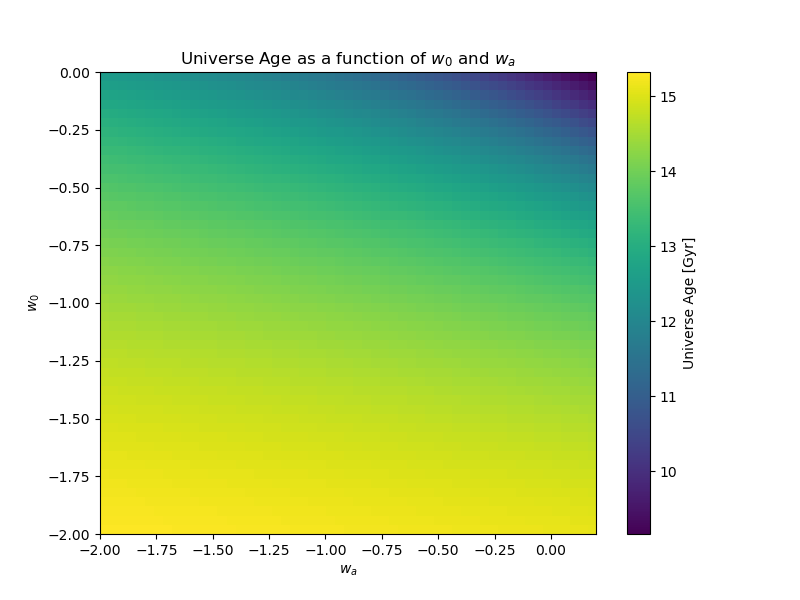

In [ ]:
# Create a heatmap visualizing how the age of the universe changes as parameters w_a and w_o change.

w_0_vals = np.linspace(-2, 0, 50)
w_a_vals = np.linspace(-2, 0.2, 55)

ages = np.zeros((len(w_0_vals), len(w_a_vals)))
for i, w_0 in enumerate(w_0_vals):
  for j, w_a in enumerate(w_a_vals):
    fe = FriedmannEquationCPL(w_0=w_0, w_a=w_a)
    ages[i,j] = fe.find_universe_age()              # i'th row of ages corresponds to i'th value of w_0_vals
                                                    # j'th col of ages corresponds to j'th value of w_a_vals

plt.figure(figsize=(8,6))
plt.imshow(ages, origin='lower', extent=[w_a_vals.min(), w_a_vals.max(), w_0_vals.min(), w_0_vals.max()],
           aspect='auto', cmap='viridis')
plt.colorbar(label='Universe Age [Gyr]')
plt.xlabel(r'$w_a$')
plt.ylabel(r'$w_0$')
plt.title('Universe Age as a function of $w_0$ and $w_a$')
plt.show()